## Exercise 3: Semantic Segmentation with CNNs

### Introduction
In this exercise, you will train a Convolutional Neural Network (CNN) to perform semantic segmentation on an image. To do this, we will write our own data loaders to handle the Potsdam Dataset. You will then train and evaluate a network and assess its performance.  
Since it is common practice to build upon existing architectures, we will use the U-Net architecture — an older but still widely used model. You can read more in the original [U-Net paper](https://arxiv.org/abs/1505.04597).

**Note:** Your submission will be evaluated automatically, so it is essential to use the predefined variable names for each task.

**Important:** As we are working with high-resolution image data, inefficient code can result in significantly longer execution times. It is strongly recommended to use vectorized operations instead of for-loops whenever possible. The autograding tool allows a maximum execution time of **10 minutes per cell**, so ensure your code runs well within this limit. With vectorized operations, all cells should execute within seconds.

**Data:** There are only the tiles `5_10`, `6_11`, `5_11` and `5_12` available.

### Dependencies
First step is to make sure that we have PyTorch and Torchvision installed in our environment. We use `!`to execute a command in the underlying system. Then we use the command `pip`, the Python Package manager, to install the required libraries in our system.

In [2]:
pip install torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 96.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 159.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 126.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 180.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 194.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 170.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 161.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 176.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 177.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 178.

In [4]:
!cp '/home/jovyan/work/__shared/utils.py' 'utils.py'
!pip install torch
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 52.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 38.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 79.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 67.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 84.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 90.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 106.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288

### Import
As usual, we need to import the necessary libraries, classes and functions into our notebook. Here I also define a few variables for later use.

In [4]:
!pip install scikit-image

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import tv_tensors
from torchvision.transforms import v2

from time import time

import utils

potsdam_root_dir = '/home/jovyan/work/__shared/'
training_tiles = ["5_10","6_11"]
validation_tiles = ["5_11"]
test_tiles = ["5_12"]

cm = ListedColormap(
    [
        [1, 1, 1], #impervious surfaces
        [0, 0, 1], #building
        [0, 1, 1], #low vegetation
        [0, 1, 0], #tree
        [1, 1, 0], #car
        [1, 0, 0]  #clutter
    ]
)
label_names = ['impervious surfaces', 'building', 'low vegetation', 'tree', 'car', 'clutter']

import os
GRADING = True if 'grader-service' in os.getcwd() else False

### 1. Data loading (10 Points)

To load the image tiles, we build upon the previous Labs. In utils.py you will find a function that uses the familiar functions from Lab 1 and 2 to load a tile or load a label and rescale them. I added some convenience that lets you choose which channels to load and build all of it into one function. When loading labels, they are directly converted to indexed labels instead of the original RGB values. Take a look at the utils.py and make sure you understand how they work.

**Task:** Use utils py to load the first training tile with only the Red and Near-Infrared Channel, scaled down to 3000x3000 pixels.

**Note:** I use these channels to compute the NDVI, this ist just for sanity check and not needed for training or anything. The NDVI has a higher value for healthy vegetation and a lower value for unhealthy vegetation and water or buildings.

[Text(1, 0.5, 'impervious surfaces'),
 Text(1, 1.25, 'building'),
 Text(1, 2.1, 'low vegetation'),
 Text(1, 2.9, 'tree'),
 Text(1, 3.75, 'car'),
 Text(1, 4.5, 'clutter')]

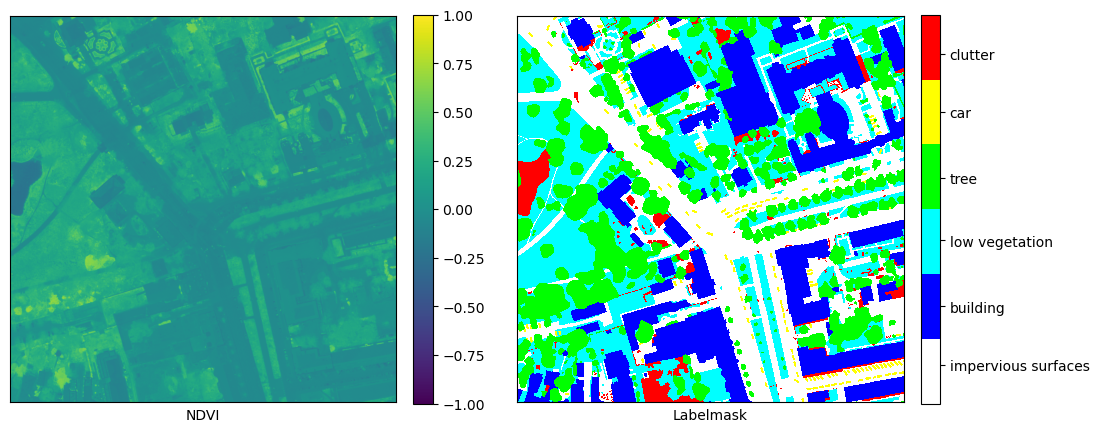

In [6]:
# YOUR CODE HERE

training_tile = utils.load_tile(
    potsdam_root_dir,
    "5_10",
    0.5,
    [0, 3]   # 0 = Red, 3 = NIR
)

training_tile_label = utils.load_label(
    potsdam_root_dir,
    "5_10",
    0.5
)


# NDVI berechnen
ndvi = (training_tile[1]-training_tile[0])/(training_tile[1]+training_tile[0])

# Plotting
fig, ax = plt.subplots(1,2, figsize=(12,6))
pos=ax[0].imshow(ndvi, vmax=1, vmin=-1)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_xlabel("NDVI")
fig.colorbar(pos, ax=ax[0],fraction=0.046, pad=0.04)
pos = ax[1].imshow(training_tile_label, cmap=cm, interpolation='nearest', vmin=0, vmax=5)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_xlabel("Labelmask")
c_bar = fig.colorbar(pos, ax=ax[1],fraction=0.046, pad=0.04)
c_bar.ax.set_yticks([0.5,1.25,2.1,2.9,3.75,4.5])
c_bar.ax.set_yticklabels(label_names)

In [7]:
assert 'training_tile' in vars(), "You need to use the variable name training_tile"
assert 'training_tile_label' in vars(), "You need to use the variable name training_tile_label"

In [ ]:
# Do not try to delete this cell. Its needed for automatic grading.

#### 1.2 Prepare Training Data

We are using the PyTorch framework in this Lab for the machine learning part. PyTorch comes with two helpful classes to prepare our data, which we can inherit into our own classes. This is simply done by passing the parent class in the bracket of your own class definition. The `Dataset` class lets you build a class that loads data with the specific needs for your dataset. You need to implement at least three functions: `__init__`, `__len__` and `__get_item__`. All other necessary functionality is implemented in the parent class `Dataset`. The `Dataloader` class can then use the `Dataset` class to load data in batches.

The computing resources are often scarce and in this case shared among many users. Especially GPU memory is a valuable resource, so we need to build our data loading structure in a way that we get good training and do not use too much GPU memory. Therefore, we crop our image into small images of 256x256 pixels without rescaling. During training, we want to show different parts of the image to the model, so we need these crops from random locations on the tile. Such a function is called a random window sampler.

**Task:** Complete the implementation of the random window sampler and inherit the Dataset class from torch.

**Note:** We want to use a generator to create a list of the loaded image tiles, usually you would not preload all the images into the RAM but bwJupyter can handle it and loading the image tile from `__shared` is time consuming, so we only want to do that once. A generator works like this: `images = [load_image for image_name in image_names]`. To perform transformations you can check the documentation from PyTorch: https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_getting_started.html

In [8]:
class RandomWindowSamplerPotsdamDataset(Dataset):
    def __init__(self, root_dir:str, tiles:list, rescale_factor:float , num_samples_per_tile=100, width=256, height=256, channels=[0,1,2], transform=None):
        """
        Initialize a RandomWindowSamplerPotsdamDataset.

        Parameters
        ----------
        root_dir : str
            Path to the root directory of the dataset.
        tiles : list
            List of strings of tiles to load.
        rescale_factor : float
            Factor to rescale the images by.
        num_samples_per_tile : int, optional
            Number of samples to draw per tile. Defaults to 100.
        width : int, optional
            Width of the samples. Defaults to 256.
        height : int, optional
            Height of the samples. Defaults to 256.
        channels : list, optional
            List of channels to load. Defaults to [0,1,2]. R=0, G=1, B=2, IR=3 nDSM=4
        transform : torch.nn.Module, optional
            Optional transform to apply to the input images and labels. Defaults to None.
        """
        self.num_tiles = len(tiles)
        self.num_samples_per_tile = num_samples_per_tile
        
        self.sample_width = width
        self.sample_height = height
        
        self.transform = transform

        self.images = [torch.from_numpy(utils.load_tile(root_dir, tile, rescale_factor, channels)) for tile in tiles]
        # TODO: Load labels into a list called self.labels, similar to the images above
        # YOUR CODE HERE
        self.labels = [torch.from_numpy(utils.load_label(root_dir, tile, rescale_factor)) for tile in tiles]

        
        self.scene_width = self.images[0].shape[2]
        self.scene_height = self.images[0].shape[1]
    
    def __len__(self):
        """
        Return the total number of samples in the dataset.
        
        Returns
        -------
        int
            The total number of samples in the dataset.
        """
        # Length for the Random window sampler is not very intuitive
        return self.num_tiles * self.num_samples_per_tile
    
    def __getitem__(self, idx:int):
        """
        Return a random sample from the dataset.

        Parameters
        ----------
        idx : int
            Index of the sample to return.

        Returns
        -------
        image : torch.Tensor
            Image with shape (channels, height, width).
        label : torch.Tensor
            Label with shape (height, width).
        """

        # Since we miht have loaded many image tiles into the RAM, we need to unravel the idx to find the right tile
        idx = int(torch.unravel_index(torch.tensor(idx), (self.num_tiles, self.num_samples_per_tile))[0])

        # Use torch.randint to find a random upper left corner pixel coordinate for the random window
        # make sure that you only use a valid range and dont get to close to the egde of the image
        # YOUR CODE HERE
        x = int(torch.randint(0, self.scene_width - self.sample_width + 1, (1,)).item())
        y = int(torch.randint(0, self.scene_height - self.sample_height + 1, (1,)).item())


        # The crops are created through indexing
        image = self.images[idx][..., y:y+self.sample_height, x:x+self.sample_width].to(torch.float32)
        label = self.labels[idx][..., y:y+self.sample_height, x:x+self.sample_width].to(torch.long)

        if self.transform is not None:
            # if we use transformations from torchvision, the tensors need to be tv_tensors, which are aware what type of tensor they are (image or mask)
            image = tv_tensors.Image(image.to(torch.float32))
            label = tv_tensors.Mask(label.to(torch.long))
            # TODO: Apply transform
            # YOUR CODE HERE
            image, label = self.transform(image, label)

        
        return image, label

    def set_random_seed(self, seed:int):
        """
        Set the random seed for PyTorch.

        Parameters
        ----------
        seed : int
            Random seed to set.
        """
        torch.manual_seed(seed)
    
    def get_class_count(self):
        """
        Return a tensor containing the number of pixels for each class in the dataset to compute class weights.

        Returns
        -------
        torch.Tensor
            A tensor containing the number of pixels for each class in the dataset.
        """
        return torch.bincount(torch.cat(self.labels).flatten())

#### 1.3 Prepare Validation Data 

During validation, we want to always look at the same image crops so that we can compare the result from each training run to the previous. So we need a class that does not sample at random location but at always the same locations from all over the tile. We want a moving window sampler.

**Task:** Complete the moving window sampler.

In [9]:
class MovingWindowSamplerPotsdamDataset(Dataset):
    def __init__(self, root_dir:str, tiles:list, rescale_factor:float, num_samples_x=12, num_samples_y=12, width=256, height=256, channels=[0,1,2], transform=None):
        """
        Initialize a MovingWindowSamplerPotsdamDataset instance.

        Parameters
        ----------
        root_dir : str
            Root directory of the dataset.
        tiles : list
            List of tile numbers to load.
        rescale_factor : float
            Rescale factor for the images.
        num_samples_x : int, optional
            Number of samples to take in the x direction. Defaults to 16.
        num_samples_y : int, optional
            Number of samples to take in the y direction. Defaults to 16.
        width : int, optional
            Width of the samples. Defaults to 256.
        height : int, optional
            Height of the samples. Defaults to 256.
        channels : list, optional
            List of channels to load. Defaults to [0, 1, 2].
        transform : callable, optional
            Transformation to apply to the samples. Defaults to None.
        """
        self.num_samples_x = num_samples_x
        self.num_samples_y = num_samples_y
        self.num_tiles = len(tiles)
        self.num_samples_per_tile = num_samples_x * num_samples_y
        
        self.transform = transform
        
        self.sample_width = width
        self.sample_height = height

        # TODO: Similar to the Random Window Sampler we want a list with all loaded tiles and one with all loaded labels
        # YOUR CODE HERE
        self.images = [torch.from_numpy(utils.load_tile(root_dir, tile, rescale_factor, channels)) for tile in tiles]
        self.labels = [torch.from_numpy(utils.load_label(root_dir, tile, rescale_factor)) for tile in tiles]


        self.scene_width = self.images[0].shape[2]
        self.scene_height = self.images[0].shape[1]

        # We want a regular grid for our moving window.
        # use numpy linspace to create arrays with the correct upper left coordinates 
        # both in x and y direction like
        # TODO:
        # self.xs = np.linspace...
        # self.ys = np.linspace...
        # YOUR CODE HERE
        self.xs = np.linspace(0, self.scene_width - self.sample_width, num=self.num_samples_x, dtype=int)
        self.ys = np.linspace(0, self.scene_height - self.sample_height, num=self.num_samples_y, dtype=int)

    
    def __len__(self):
        """
        Return the total number of samples in the dataset.
        
        Returns
        -------
        int
            The total number of samples in the dataset.
        """
        # The length of the dataset is determined by the number of induviudal crops that can be returned by the dataset
        # TODO: Return length of dataset
        # YOUR CODE HERE
        return self.num_tiles * self.num_samples_per_tile

    
    def __getitem__(self, idx:int):
        """
        Return the sample at position idx from the dataset.

        Parameters
        ----------
        idx : int
            Index of the sample to return.

        Returns
        -------
        image : torch.Tensor
            Sample image with shape (channels, height, width).
        label : torch.Tensor
            Sample label with shape (height, width).
        """
        # Index is running up to the maximum length of the Dataset. To find the right tile we need to unravel the index.
        # then we can use the unraveld indices to find the right x and y coordinate of the upper left corner from the numpy arrays defined in the __init__ function
        #TODO: unravel the indeices
        #TODO: fetch the pixel position from the predefined xs and ys
        # YOUR CODE HERE
        tile_idx, grid_idx = torch.unravel_index(torch.tensor(idx), (self.num_tiles, self.num_samples_per_tile))
        tile_idx = int(tile_idx.item())
        grid_idx = int(grid_idx.item())

        y_idx, x_idx = np.unravel_index(grid_idx, (self.num_samples_y, self.num_samples_x))
        x = int(self.xs[x_idx])
        y = int(self.ys[y_idx])

        idx = tile_idx


        image = self.images[idx][..., y:y + self.sample_height, x:x + self.sample_width].to(torch.float32)
        label = self.labels[idx][..., y:y + self.sample_height, x:x + self.sample_width].to(torch.long)
        
        if self.transform is not None:
            # TODO: Similar to RandomWindowSamplerPotsdamDataset
            # YOUR CODE HERE
            image = tv_tensors.Image(image.to(torch.float32))
            label = tv_tensors.Mask(label.to(torch.long))
            image, label = self.transform(image, label)

        
        return image, label
        
    def get_class_count(self):
        return torch.bincount(torch.cat(self.labels).flatten())

#### 1.4 Prepare Dataset instances

Now we need to create instances from our Dataset classes with the specific wanted traits for our training. We will use Normalization for both, training and validation dataset. For training, you can choose further techniques from PyTorch v2. Pick the channels of which you think will give you the highest accuracy for semantic segmentation.

**Task:** Define the transformations. Then create an instance of the random window sampler with the training tiles and an instance of the moving window sampler of the validation tiles and another moving window sampler from the test tile.

**Note:** V2 transforms: https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_getting_started.html

In [10]:
# TODO: define channels as list of your preferred channels
# TODO: define num_channels as number of channels
# TODO: define transformations
# TODO: create datasets
# YOUR CODE HERE
# choose channels (RGB + NIR usually works well)

import torchvision.transforms.v2 as T

# choose channels
channels = [0, 1, 2, 3]   # R, G, B, NIR
num_channels = len(channels)

# define transformations
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.Normalize(mean=[0.5] * num_channels, std=[0.5] * num_channels),
])

val_transform = T.Compose([
    T.Normalize(mean=[0.5] * num_channels, std=[0.5] * num_channels),
])

# create dataset instances
training_set = RandomWindowSamplerPotsdamDataset(
    root_dir=potsdam_root_dir,
    tiles=training_tiles,
    rescale_factor=0.5,
    num_samples_per_tile=100,
    width=256,
    height=256,
    channels=channels,
    transform=train_transform
)

validation_set = MovingWindowSamplerPotsdamDataset(
    root_dir=potsdam_root_dir,
    tiles=validation_tiles,
    rescale_factor=0.5,
    width=256,
    height=256,
    channels=channels,
    transform=val_transform
)

test_set = MovingWindowSamplerPotsdamDataset(
    root_dir=potsdam_root_dir,
    tiles=test_tiles,
    rescale_factor=0.5,
    width=256,
    height=256,
    channels=channels,
    transform=val_transform
)


In [11]:
assert 'channels' in vars(), "You need to use the variable name 'channels'"
assert 'num_channels' in vars(), "You need to use the variable name 'num_channels'"
assert 'training_set' in vars(), "You need to use the variable name 'training_set'"
assert 'validation_set' in vars(), "You need to use the variable name 'validation_set'"
assert 'test_set' in vars(), "You need to use the variable name 'test_set'"

**1. Question:** Why do we not apply any transformations to the validation and test set except normalization?

We do not apply data augmentations to the validation and test sets because they are meant to provide a fixed and unbiased evaluation of the model’s performance.
Augmentations such as flips or random transformations would change the input data and introduce randomness, making the evaluation results inconsistent and not directly comparable across different training runs or models.

Normalization is still applied because it is not a data augmentation; it is a deterministic preprocessing step that ensures the input data has the same scale and distribution as the training data. This is necessary so that the network receives inputs in the same numerical range during training, validation, and testing, enabling a fair and stable evaluation.

##### 1.4.1 Visualize Dataset 

**Task:** To make sure that transformations and cropping works as expected, we plot one image of the training set and one of the validations set alongside with their labels.

Text(0.5, 0, 'Labelmask from validation set')

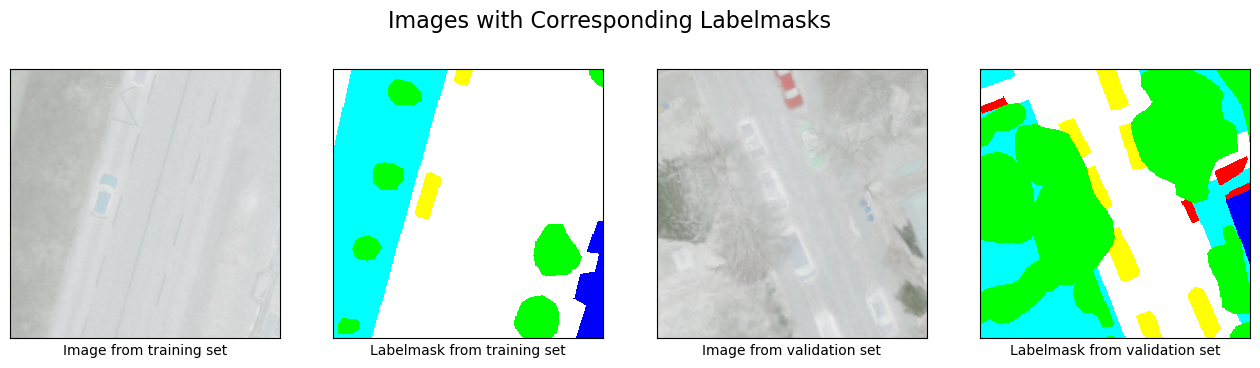

In [12]:
training_set.set_random_seed(42) # Do not change this line

# Use indexing to get the first crops from the datasets. For visualization you might have to adapt a view things, like shape and range of values.
# YOUR CODE HERE
# get one crop from training and validation set
train_img, train_lbl = training_set[0]
val_img, val_lbl = validation_set[0]

# undo normalization for visualization: x = x*std + mean, with mean=std=0.5
train_img_vis = train_img * 0.5 + 0.5
val_img_vis = val_img * 0.5 + 0.5

# convert CHW -> HWC for matplotlib
training_image_crop = train_img_vis.permute(1, 2, 0).cpu().numpy()
validation_image_crop = val_img_vis.permute(1, 2, 0).cpu().numpy()

# labels for plotting
training_label_crop = train_lbl.cpu().numpy()
validation_label_crop = val_lbl.cpu().numpy()


# Do not chnage the code below
fig, ax = plt.subplots(1,4, figsize = (16,4))
fig.suptitle('Images with Corresponding Labelmasks', fontsize=16)
ax[0].imshow(training_image_crop)
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[0].set_xlabel("Image from training set")
ax[1].imshow(training_label_crop, cmap=cm, interpolation='nearest', vmin=0, vmax=5)
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_xlabel("Labelmask from training set")
ax[2].imshow(validation_image_crop)
ax[2].set_xticks([])
ax[2].set_yticks([])
ax[2].set_xlabel("Image from validation set")
ax[3].imshow(validation_label_crop, cmap=cm, interpolation='nearest', vmin=0, vmax=5)
ax[3].set_xticks([])
ax[3].set_yticks([])
ax[3].set_xlabel("Labelmask from validation set")


In [ ]:
# Do not try to delete this cell. Its needed for automatic grading.

### 2. Choose Network Architecture - Model (2 Points)

We want to use the U-Net model, and luckily we don't have to build it ourselves (which would also be possible) but we can use what others provide for us. Furthermore, we can get pretrained weights with it, which might help us during training. On torch hub, we can find a U-Net trained on medical MRI images of brains. That is not exactly what we are looking for but if we are lucky the first layers capture basic features like edges and blobs, that are universal and might accelerate our training as well. 

**Task:** Load the model with torch.hub.load. Keep it to the correct in_channels, out_channels and init_features to be able to use the pretrained weights. Then print the model to see the structure.

**Note:** You can find documentation for the model here: https://pytorch.org/hub/mateuszbuda_brain-segmentation-pytorch_unet/

In [13]:
# YOUR CODE HERE
import torch

model = torch.hub.load(
    "mateuszbuda/brain-segmentation-pytorch",
    "unet",
    in_channels=3,
    out_channels=1,
    init_features=32,
    pretrained=True,
    trust_repo=True
)

print(model)



Downloading: "https://github.com/mateuszbuda/brain-segmentation-pytorch/zipball/master" to /home/jovyan/.cache/torch/hub/master.zip
Downloading: "https://github.com/mateuszbuda/brain-segmentation-pytorch/releases/download/v1.0/unet-e012d006.pt" to /home/jovyan/.cache/torch/hub/checkpoints/unet-e012d006.pt
UNet(
  (encoder1): Sequential(
    (enc1conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc1norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc1relu1): ReLU(inplace=True)
    (enc1conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc1norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc1relu2): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): Sequential(
    (enc2conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fa

In [14]:
assert 'model' in vars(), "You need to use the variable name 'model'"

In [ ]:
# Do not try to delete this cell. Its needed for automatic grading.

#### 2.1 Patching

The model from torch hub with pretrained weights does not match exactly the shape of our data. We might need to change the first layer, depending on your channel choice, and we definitely need to change the last layer to fit our 6 classes.

**Task:** Patch the layers to fit our model. You can look up the names from the layers from printing the model in the previous task. Print the model again to verify that the changes took place. Use `torch.rand` of chosen input shape to feet a random image to the model as a test.

In [15]:
# YOUR CODE HERE
import torch
import torch.nn as nn

# ---- Patch first conv layer (input channels) ----
if num_channels != 3:
    old_conv = model.encoder1.enc1conv1  # Conv2d(3, 32, 3x3, padding=1, bias=False)
    model.encoder1.enc1conv1 = nn.Conv2d(
        in_channels=num_channels,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        dilation=old_conv.dilation,
        groups=old_conv.groups,
        bias=(old_conv.bias is not None),
        padding_mode=old_conv.padding_mode,
    )

# ---- Patch last layer (output classes = 6) ----
old_head = model.conv  # Conv2d(32, 1, kernel_size=1)
model.conv = nn.Conv2d(
    in_channels=old_head.in_channels,
    out_channels=6,
    kernel_size=old_head.kernel_size,
    stride=old_head.stride,
    padding=old_head.padding,
    bias=(old_head.bias is not None),
)

# ---- Verify ----
print(model)

# test forward pass with random tensor (batch=1, channels=num_channels, H=W=256)
x = torch.rand(1, num_channels, 256, 256)
y = model(x)
print("Output shape:", y.shape)  # expected: (1, 6, 256, 256)


UNet(
  (encoder1): Sequential(
    (enc1conv1): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc1norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc1relu1): ReLU(inplace=True)
    (enc1conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc1norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc1relu2): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): Sequential(
    (enc2conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc2norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc2relu1): ReLU(inplace=True)
    (enc2conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc2norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [ ]:
# Do not try to delete this cell. Its needed for automatic grading.

#### 2.2 GPU

A great advantage of that accelerated deep learning and CNNs is the use of GPUs and their parallel computing power. We have a GPU available (that we share with everyone on a fair use policy), so we want to move our model and data to that device. PyTorch makes that very easy for us.

**Task:** Check if a GPU is available and move the model to the GPU memory if it is available.

In [16]:
# YOUR CODE HERE
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA L40S


In [ ]:
# Do not try to delete this cell. Its needed for automatic grading.

### 3. Choose Hyperparameters

Now we need to define our hyperparameters for training. They decide how well we can train our model. They need to balance the pace of the learning and the available resources. 

#### 3.1 Class Weights

Since we are dealing with a real world scene, we can not expect to have a balanced dataset. If one class is very dominant, the model will quickly learn that it is a save bet to always choose the most prominent classes. To counter that, we need to give weights to the loss function, to punish mistakes on less frequent classes harder. The weights should be inversely proportional to the class counts, which you get from the provided convenience function from the custom dataset classes `get_class_count()`. 

The standard choice for class imbalance is the inverse frequency class weights:

$$weights = \frac{N}{K\cdot n_c}$$

$$N: \text{Number of samples}$$

$$K: \text{Number of classes}$$

$$n_c: \text{per class counts}$$



**Task:** Use get_class_count() function from our training dataset instance to calculate the class weights. 

In [17]:
# YOUR CODE HERE
import torch

# pixel counts per class (length K=6)
class_counts = training_set.get_class_count().to(torch.float32)

K = class_counts.numel()
N = class_counts.sum()

# inverse frequency weights
class_weights = N / (K * class_counts)

# (optional but often helpful) normalize weights to mean 1
class_weights = class_weights / class_weights.mean()

print("class_counts:", class_counts)
print("class_weights:", class_weights)


class_counts: tensor([5383526., 6084678., 2876794., 2674959.,  279493.,  700550.])
class_weights: tensor([0.1834, 0.1623, 0.3432, 0.3691, 3.5326, 1.4094])


In [ ]:
# Do not try to delete this cell. Its needed for automatic grading.

#### 3.2 The Other Hyperparameters

Now we choose the remaining hyperparameters for training. We need to know how many training cycles (epochs) should run, how many images are shown to the network at once (batch_size), what loss function to use, which optimizer, do we want to keep the learning rate constant or do we use a learning rate scheduler? 

**Task:** Choose good `num_epoch`, `batch_size`, `learining_rate`, `loss_fn` and `optimizer` for efficient training and efficient memory consumption.

In [18]:
# YOUR CODE HERE
import torch
import torch.nn as nn

# training hyperparameters
num_epochs = 10
batch_size = 8
learning_rate = 1e-3

# loss function (multi-class segmentation)
loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [19]:
assert 'num_epochs' in vars(), "You need to use the variable name 'num_epochs'"
assert 'batch_size' in vars(), "You need to use the variable name 'batch_size'"
assert 'learning_rate' in vars(), "You need to use the variable name 'learning_rate'"
assert 'loss_fn' in vars(), "You need to use the variable name 'loss_fn'"
assert 'optimizer' in vars(), "You need to use the variable name 'optimizer'"

**2. Question:** What is an optimizer, and what role does it play in training a neural network? In your explanation, include the significance of the provided parameters: *learning rate* and *weight decay*.

An optimizer is the algorithm responsible for updating the model’s parameters (weights and biases) during training in order to minimize the loss function. It uses the gradients computed by backpropagation to decide how each parameter should be adjusted at every training step.

The learning rate controls the step size of these updates. If the learning rate is too large, the optimizer may overshoot the minimum and cause unstable training or divergence. If it is too small, training becomes very slow and may get stuck in suboptimal solutions.

Weight decay is a regularization term that penalizes large weights by adding an L2 penalty to the loss. Its role is to reduce overfitting by encouraging simpler models with smaller parameter values, which generally improves generalization to unseen data.

**3. Question:**  What are the advantages and potential risks of using a learning rate scheduler?

A learning rate scheduler automatically adjusts the learning rate during training, typically decreasing it over time. This allows the model to make large, fast updates in the early training phase and smaller, more precise updates later, which can lead to better convergence and improved final performance.

However, there are potential risks. If the learning rate is reduced too quickly, the model may stop learning before reaching a good solution. If the schedule is poorly chosen or not suited to the dataset and model, it can lead to underfitting or unnecessarily long training times. Therefore, learning rate schedulers must be chosen carefully and matched to the training setup.

#### 3.3 Dataloaders, logging and device

As the last step before the training loop, we need to create the dataloaders and create a dict for logging the training progress.

**Task:** Create data loaders for all three datasets. Use the predefined batch size. Make sure to use `shuffle=True` on training dataloader but not on validation and test dataloader.

In [20]:
# YOUR CODE HERE
from torch.utils.data import DataLoader

# Training dataloader (shuffle = True)
training_dataloader = DataLoader(
    training_set,
    batch_size=batch_size,
    shuffle=True
)

# Validation dataloader (shuffle = False)
validation_dataloader = DataLoader(
    validation_set,
    batch_size=batch_size,
    shuffle=False
)

# Test dataloader (shuffle = False)
test_dataloader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False
)

# logging dictionary (already defined, keep it)
log = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

log = {'train_loss':[],'train_acc':[], 'val_loss':[], 'val_acc':[]}

In [21]:
assert 'training_dataloader' in vars(), "You need to use the variable name 'training_dataloader'"
assert 'validation_dataloader' in vars(), "You need to use the variable name 'validation_dataloader'"
assert 'test_dataloader' in vars(), "You need to use the variable name 'test_dataloader'"

In [ ]:
# Do not try to delete this cell. Its needed for automatic grading.

### 4. Training (fine-tuning)

Finally, we can build our training loop. We want to iterate many times over the training dataset. Luckily, PyTorch deals with the backpropagation and weight adjustment automatically, we just need to make sure that the model is in training mode. For each batch, we need to 
1. move image and label crop to the correct device.
2. reset the gradients in the optimizer.
3. present the batch to the model.
4. compute the loss.
5. calculate the gradients using backpropagation.
6. make an optimization step.
8. track metrics (loss and accuracy).

After each time, we presented all training images to the model we want to validate the current state. We can do that without computing gradients and we can set the model to evaluation mode to safe computation load. We present the validation set to the image in a similar procedure:
1. move image and label crop to the correct device.
2. present the batch to the model.
3. compute the loss.
4. track metrics (loss and accuracy).

At the end of each epoch we:
1. track our metrics in the logging dict.
2. print the metrics nicely.
3. save the best model for later use.
4. optional: make a scheduler step.

**Task:** Complete the training loop.

**Note:** If you get an out of GPU memory error, just wait some time, probably someone else is using the GPU at the moment. 

In [22]:
# Do not try to delete this cell. Its needed for automatic grading.
if GRADING:
    num_epochs = 1

In [23]:
best_score = 1000 # arbitrary high loss
for e in range(num_epochs):
    start = time()
    
    # TODO: Set the model to trainng mode
    # YOUR CODE HERE
    model.train()

    
    running_train_loss = 0
    running_train_acc = 0
    running_valid_loss = 0
    running_valid_acc = 0
    
    for x, y in training_dataloader:
        # TODO: Move the image and the labelmask to the correct dvice
        # TODO: set the gradients in the optimizer to zero 
        # TODO: Forward pass
        # TODO: Calculate loss (variable needs to be named 'loss')
        # TODO: Bachward pass
        # TODO: Otimizer step
        # YOUR CODE HERE
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        
        running_train_loss += loss.item()
        running_train_acc += float((pred.argmax(dim=1) == y).sum()) / (y.numel())
    with torch.no_grad(): 
        # TODO: Set model to evaluation mode
        # YOUR CODE HERE
        model.eval()

        
        for x, y in validation_dataloader:
            # TODO: Move the image and the labelmask to the correct dvice
            # TODO: Forward pass
            # TODO: Calculate loss (variable needs to be named 'loss')
            # YOUR CODE HERE
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = loss_fn(pred, y)

            
            running_valid_loss += loss.item()
            running_valid_acc += float((pred.argmax(dim=1) == y).sum()) / (y.numel())
    log['train_loss'].append(running_train_loss/len(training_dataloader))
    # TODO: Log the three remaining training metrics
    # TODO: Optional: make scheduler step
    # YOUR CODE HERE
    log['train_acc'].append(running_train_acc / len(training_dataloader))
    log['val_loss'].append(running_valid_loss / len(validation_dataloader))
    log['val_acc'].append(running_valid_acc / len(validation_dataloader))

    # optional scheduler step
    if 'scheduler' in globals():
        scheduler.step()

    
    if log['val_loss'][-1] < best_score:
        best_score = log['val_loss'][-1]
        if not GRADING:
            torch.save(model.state_dict(),f"UNet_best_model.pt")
    print(f'Epoch {e+1} \tTime: {(time()-start):.0f}s\tTraining Loss: {log["train_loss"][-1]:.2f}\tValidation Loss: {log["val_loss"][-1]:.2f}\tTraining Accuracy: {log["train_acc"][-1]:.2f}\tValidation Accuracy: {log["val_acc"][-1]:.2f}\tLearning Rate: {optimizer.param_groups[0]['lr']}')
if not GRADING:
    with open("log.json", "w") as f:
        json.dump(log, f)

Epoch 1 	Time: 6s	Training Loss: 1.66	Validation Loss: 1.61	Training Accuracy: 0.48	Validation Accuracy: 0.47	Learning Rate: 0.001
Epoch 2 	Time: 6s	Training Loss: 1.57	Validation Loss: 1.50	Training Accuracy: 0.62	Validation Accuracy: 0.66	Learning Rate: 0.001
Epoch 3 	Time: 6s	Training Loss: 1.53	Validation Loss: 1.46	Training Accuracy: 0.63	Validation Accuracy: 0.63	Learning Rate: 0.001
Epoch 4 	Time: 5s	Training Loss: 1.46	Validation Loss: 1.43	Training Accuracy: 0.63	Validation Accuracy: 0.66	Learning Rate: 0.001
Epoch 5 	Time: 6s	Training Loss: 1.44	Validation Loss: 1.44	Training Accuracy: 0.65	Validation Accuracy: 0.57	Learning Rate: 0.001
Epoch 6 	Time: 7s	Training Loss: 1.41	Validation Loss: 1.43	Training Accuracy: 0.66	Validation Accuracy: 0.62	Learning Rate: 0.001
Epoch 7 	Time: 6s	Training Loss: 1.40	Validation Loss: 1.47	Training Accuracy: 0.67	Validation Accuracy: 0.50	Learning Rate: 0.001
Epoch 8 	Time: 6s	Training Loss: 1.41	Validation Loss: 1.39	Training Accuracy: 0.65

#### 4.1 Plotting training 

Finally, we plot the training nicely so that we can judge if we trained successfully. If you do not like what they look like, you can tweak the hyperparameters and try again.

**Task:** Make pretty plots of the training metrics.

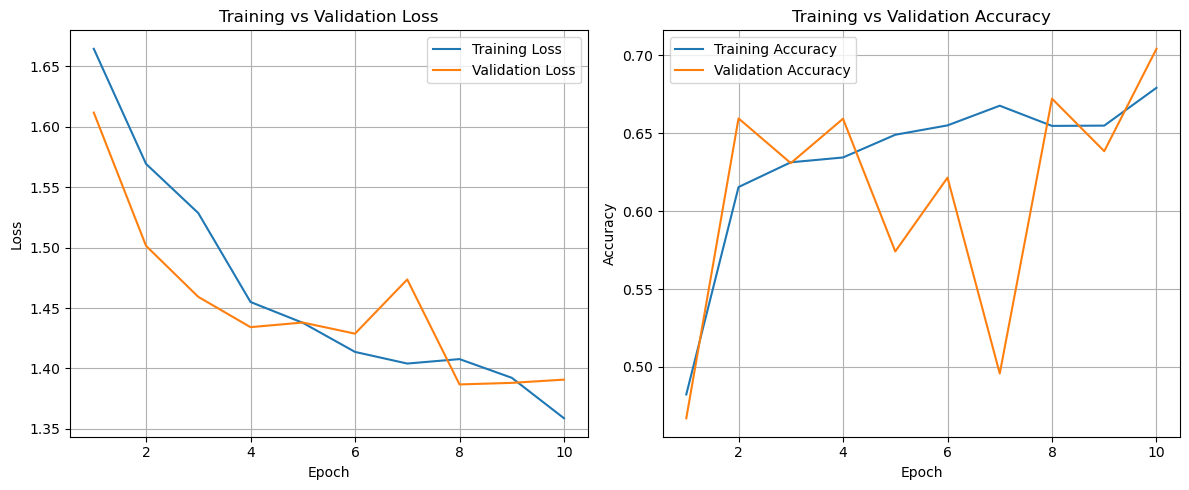

In [24]:
with open("log.json", "r") as f:
    log = json.load(f)
# YOUR CODE HERE
import matplotlib.pyplot as plt

epochs = range(1, len(log['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# ---- Loss plot ----
plt.subplot(1, 2, 1)
plt.plot(epochs, log['train_loss'], label='Training Loss')
plt.plot(epochs, log['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# ---- Accuracy plot ----
plt.subplot(1, 2, 2)
plt.plot(epochs, log['train_acc'], label='Training Accuracy')
plt.plot(epochs, log['val_acc'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


**4. Question:** Describe the training curves. What could explain their behavior?

The training loss decreases steadily over the epochs, indicating that the model is successfully learning from the training data. At the same time, the training accuracy increases, which confirms that the predictions on the training set are improving.

The validation loss follows a similar decreasing trend, especially in the early epochs, which suggests good generalization. The validation accuracy also increases overall but shows some fluctuations. These fluctuations can be explained by the limited size of the validation set, random cropping, class imbalance, and the stochastic nature of mini-batch training.

The relatively small gap between training and validation curves indicates that the model is not strongly overfitting. Overall, the curves suggest stable training with reasonable hyperparameter choices and effective use of regularization and data augmentation

**5. Question:** What happens to the loss and accuracy when the `learning_rate` is increased significantly (e.g., to `1.0`) or decreased significantly (e.g., to `0.000001`)?  

 If the learning rate is increased significantly (e.g., to 1.0), the optimization steps become too large. As a result, the loss may oscillate or even diverge instead of decreasing, and the accuracy may remain low or unstable. In extreme cases, the model may fail to learn altogether.

If the learning rate is decreased significantly (e.g., to 0.000001), the optimization steps become very small. This leads to very slow convergence: the loss decreases only slightly or appears almost constant, and the accuracy improves very slowly. The model may not reach a good solution within a reasonable number of epochs.

Therefore, choosing an appropriate learning rate is crucial to ensure both stable convergence and efficient training.

### 5. Evaluation

So far, we used the loss and the overall accuracy as metrics. More interesting and common is the per class intersection over union (IoU) and the mean IoU. Often this is done with bounding boxes. For each bounding box, you calculate the area of the intersection of the ground truth and predicted bounding box, as well the area of their union. You find that in the lecture slides. In our case we have a prediction mask, no bounding boxes, so we get the area simply by summing the pixels of each class.

One way of getting there is to convert the label and the prediction to one-hot representation, where you get an image with a channel for each class and the value is one at only one channel for each pixel position. When we convert this representation to boolean we can use `bitwise_and` and the union with `bitwise_or`. To get the area, you only need to sum each over the whole batch and pixels. Finally, you can calculate the fraction. If both intersection and union are zero, that happens when a class is not present in an image and the model correctly did not classify any pixel as that class, the IoU should be one.

**Task:** Complete a function that computes the per class intersection over union for a batch of images.

**Note:** `torch.nn.functional` comes with a handy function that can convert index labels to one hot representation. With `.argmax` you can convert the prediction from the network to a index label representation.

In [25]:
import torch
import torch.nn.functional as F

In [26]:
def compute_IoU(prediction, label):
    """
    Compute the Intersection over Union (IoU) for a given prediction and label.

    Parameters
    ----------
    prediction : torch.Tensor
        Prediction with shape (batch_size, num_classes, height, width).
    label : torch.Tensor of type LongTensor
        Label with shape (batch_size, height, width).

    Returns
    -------
    IoU : torch.Tensor
        IoU score with shape (batch_size, num_classes).
    """
    num_classes = prediction.shape[1]
    
    # TODO: Convert to one hot
    # TODO: Compute intersection and union
    # TODO: Sum over all batches and pixels to compute area of pixels
    # TODO: Calulate intersection over union
    # TODO: Take care of intersection and union being zero
    # YOUR CODE HERE
    # Convert prediction to index labels (B,H,W)
    pred_idx = prediction.argmax(dim=1)

    # Convert to one-hot (B,C,H,W)
    pred_oh  = F.one_hot(pred_idx, num_classes=num_classes).permute(0, 3, 1, 2).bool()
    label_oh = F.one_hot(label,    num_classes=num_classes).permute(0, 3, 1, 2).bool()

    # Compute intersection and union per class per image
    intersection = (pred_oh & label_oh).sum(dim=(2, 3)).float()  # (B,C)
    union        = (pred_oh | label_oh).sum(dim=(2, 3)).float()  # (B,C)

    # IoU; if union==0 -> IoU=1
    iou = torch.where(union > 0, intersection / union, torch.ones_like(union))

    return iou
    

    

    


In [43]:
# Do not try to delete this cell. Its needed for automatic grading.

#### 5.1 Evaluation on Testset

To evaluate the best model, we now want to use the IoU. Use the test_dataloader to create the predictions in a similar loop, like the validation loop. You receive 1 point for reaching a mean IoU of greater than 0.2, 2 more Points for a mean IoU of greater than 0.45, and 3 more points for a mean IoU of greater than 0.59. If you are not satisfied with the performance of the model, you can go back and tweak any hyperparameter you like. Remember that the resources are shared, so dont choose a too high `batch_size` or `num_epochs`

**Task:** Process the test data and evaluate with IoU.

In [29]:
running_IoU = torch.zeros(6)

# TODO: Load best state that was saved during training
# TODO: Move model to correct device
# TODO: Set model to evaluation
# TODO: Use torch.no_grad()
# TODO: Loop through test_dataloader
# TODO: Move image to correct device
# TODO: Forwardpass
# TODO: track running IoU
# YOUR CODE HERE
# Load best state (saved during training)
state = torch.load("UNet_best_model.pt", map_location=device)
model.load_state_dict(state)
model.to(device)
model.eval()

with torch.no_grad():
    for x, y in test_dataloader:
        x = x.to(device)
        y = y.to(device)

        pred = model(x)
        
        last_x = x.detach().cpu()
        last_y = y.detach().cpu()
        last_pred = pred.detach().cpu()
        
        batch_iou = compute_IoU(pred, y).mean(dim=0).cpu()
        running_IoU += batch_iou



IoU = running_IoU/len(test_dataloader)
result = "\n".join([f"{label}: {score:.2f}" for label, score in zip(label_names,IoU)])
print(f"{result}\n______________\nmean IoU: {IoU.mean():.2f}")

impervious surfaces: 0.40
building: 0.61
low vegetation: 0.29
tree: 0.42
car: 0.25
clutter: 0.04
______________
mean IoU: 0.34


In [ ]:
# Do not try to delete this cell. Its needed for automatic grading.

In [ ]:
# Do not try to delete this cell. Its needed for automatic grading.

In [ ]:
# Do not try to delete this cell. Its needed for automatic grading.

**6. Question:** Discuss the classification performance based on the IoU. What does it reveal about the strengths and weaknesses of the trained model?

The IoU-based evaluation shows that the model performs better on large, homogeneous classes such as impervious surfaces and buildings, which typically achieve higher IoU scores. This indicates that the model is able to capture stable spatial patterns and well-defined boundaries for dominant classes.

In contrast, lower IoU values for smaller or visually complex classes such as cars, trees, or clutter reveal the model’s weakness in handling fine details and objects with high intra-class variability. These classes are more sensitive to class imbalance and resolution limitations, leading to misclassification and fragmented predictions.

Overall, the IoU results suggest that the model has strong performance on dominant land-cover classes but struggles with small or underrepresented classes. This highlights the need for improved class balancing, higher-resolution inputs, or additional data augmentation to enhance performance on challenging categories.

#### 5.2 Visual Evaluation
Lastly, we want a visualization of the result.

**Task:** Use the last loaded batch from the evaluation on the testset to visualize the image crop, the label and the prediction next to each other. 

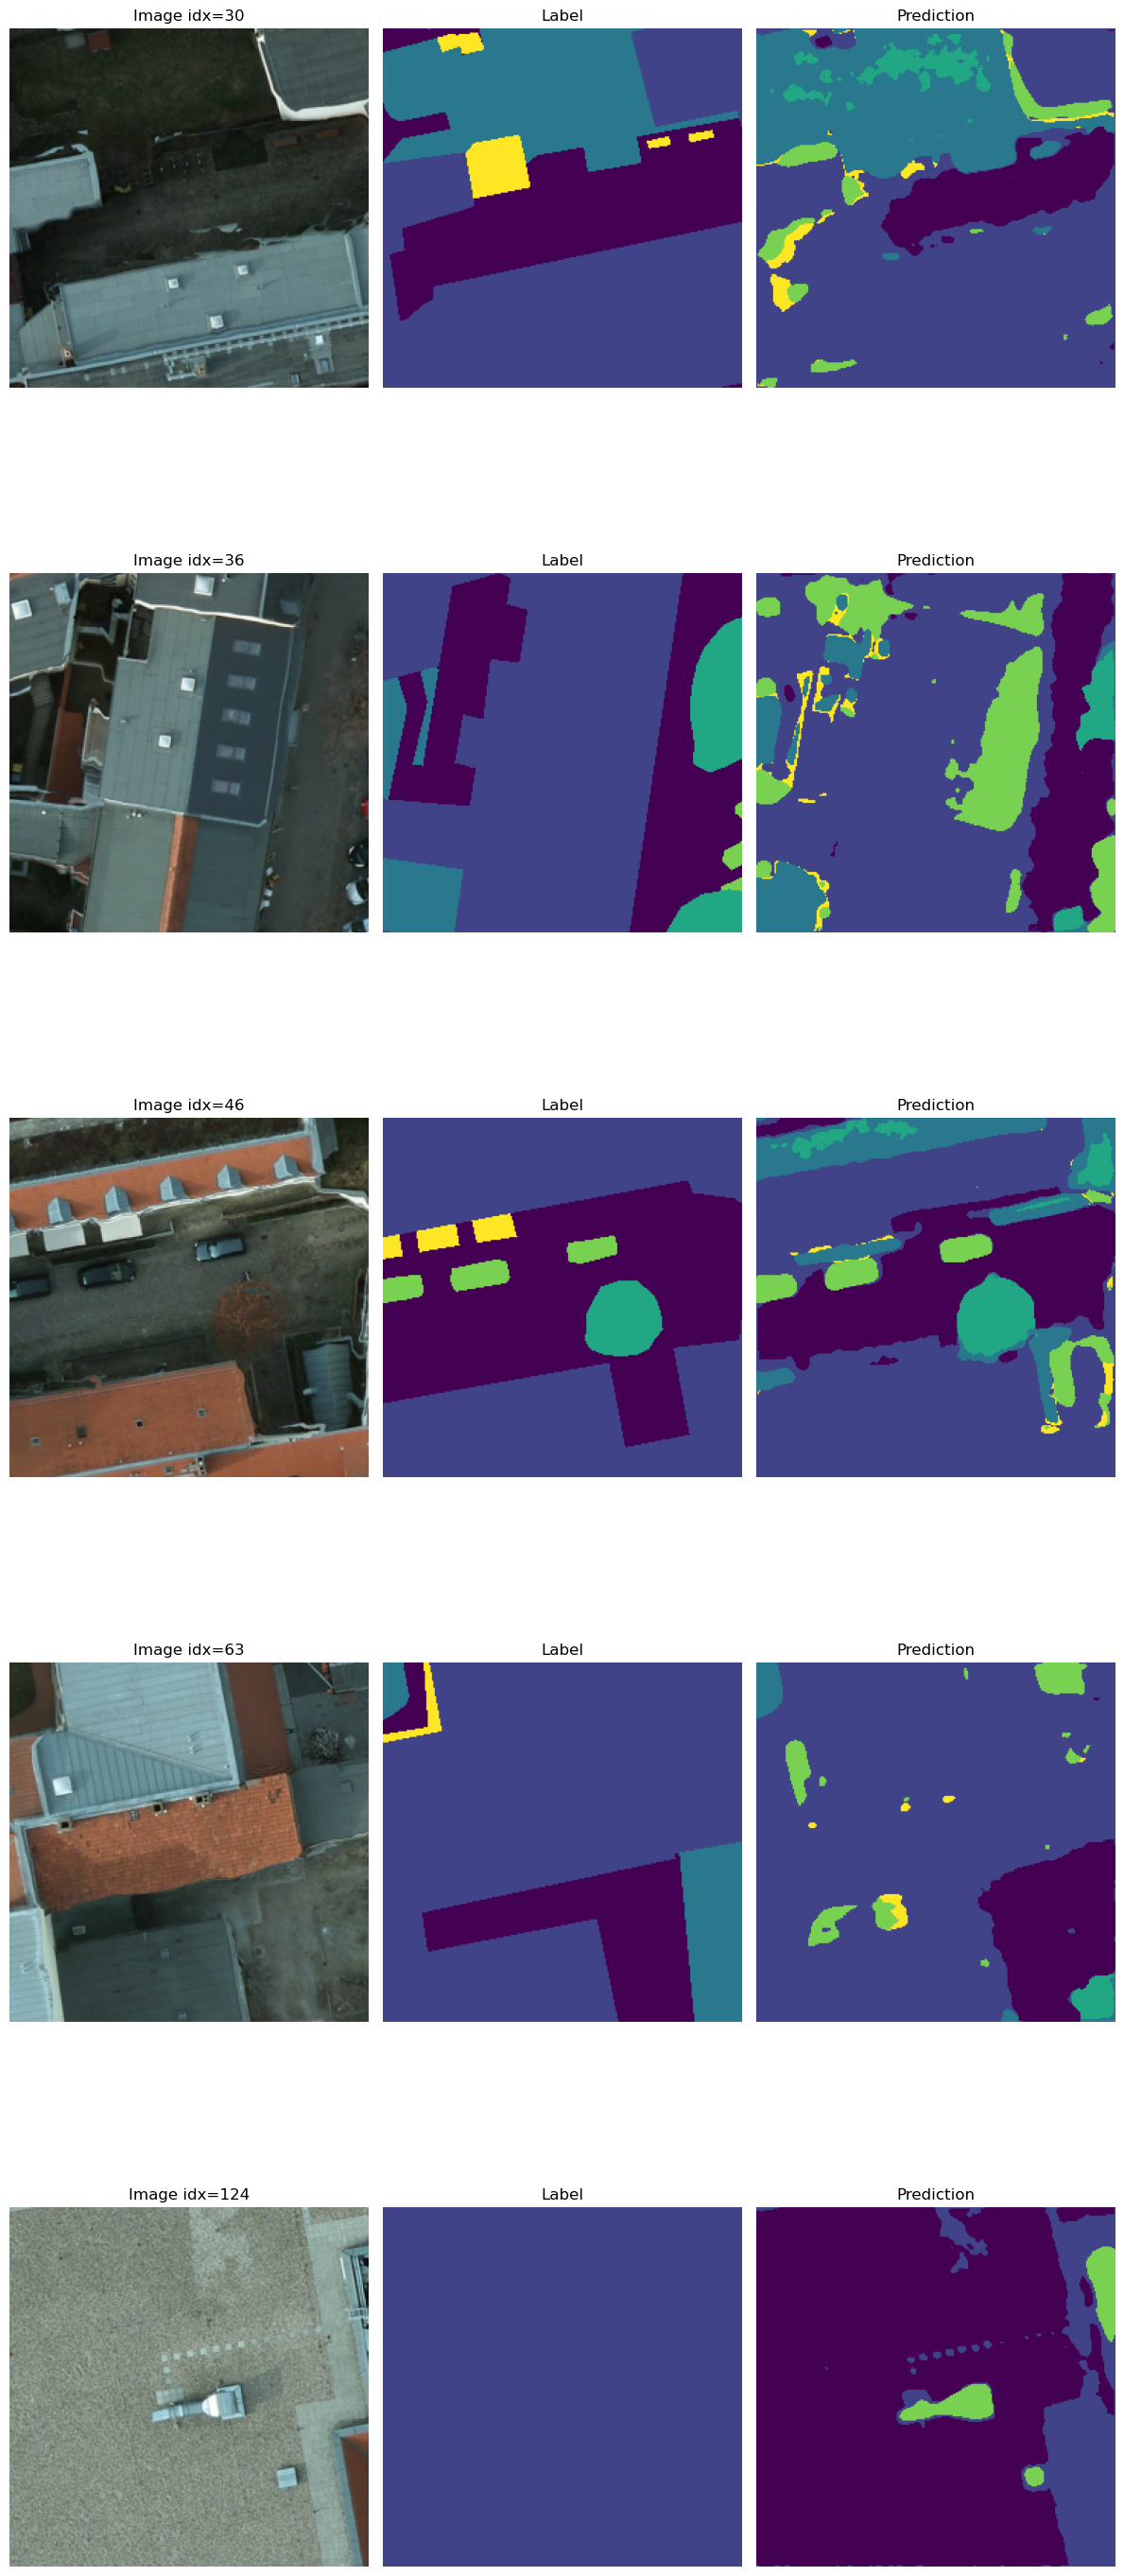

In [30]:
import matplotlib.pyplot as plt

idx = [30, 36, 46, 63, 124]

fig, ax = plt.subplots(len(idx), 3, figsize=(12, 30))

model.eval()

for num, i in enumerate(idx):
    # Get sample from test_set
    x, y = test_set[i]                 # x: (C,H,W), y: (H,W)

    # Move image to device
    x = x.to(device)

    # Forward pass (add batch dimension)
    with torch.no_grad():
        logits = model(x[None, ...])           # (1,C,H,W)
        pred = logits.argmax(dim=1).squeeze(0) # (H,W)

    # Detach and move to cpu
    x_np = x.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy()
    p_np = pred.detach().cpu().numpy()

    # Choose channels to display (first 3 channels)
    img = x_np[:3].transpose(1, 2, 0)

    # Normalize image for matplotlib
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)

    # Plot image
    ax[num, 0].imshow(img)
    ax[num, 0].set_title(f"Image idx={i}")
    ax[num, 0].axis("off")

    # Plot label
    ax[num, 1].imshow(y_np, vmin=0, vmax=5)
    ax[num, 1].set_title("Label")
    ax[num, 1].axis("off")

    # Plot prediction
    ax[num, 2].imshow(p_np, vmin=0, vmax=5)
    ax[num, 2].set_title("Prediction")
    ax[num, 2].axis("off")

plt.tight_layout()


**7. Question:** Describe and judge the visual results briefly. What stands out to you? Which classes perform well? Which perform poorly? Why could that be?

The visual results show that large and spatially consistent classes such as impervious surfaces and buildings are segmented clearly with coherent regions and relatively sharp boundaries. These classes stand out positively due to their strong spectral and spatial characteristics.

Smaller and more heterogeneous classes such as cars, trees, and clutter perform noticeably worse. Predictions for these classes are often fragmented or confused with surrounding classes. This can be explained by their small object size, high intra-class variability, class imbalance, and limited spatial resolution, which make accurate segmentation more challenging.

### 6. Review on Semantic Segmentation via CNNs - Questions (5 Points)
This part is designed to reinforce your understanding and prepare you for the exam.

**8. Question:** What are advantages and disadvantages of using deep learning compared to Random Forests (RF)? Think about training data requirements, traceability of the decision-making process, performance, etc. 

Deep learning models can automatically learn complex spatial and hierarchical features directly from raw data, which often leads to superior performance in tasks such as semantic segmentation. They are especially effective for large datasets and complex patterns.

However, deep learning requires large labeled datasets, high computational resources, and long training times. The decision-making process is also less interpretable compared to Random Forests. In contrast, Random Forests are easier to train, more interpretable, work well with smaller datasets, and require less computational power, but they generally struggle to model complex spatial dependencies

**9. Question:** Neural networks can be thought of as parametric function approximations. What are the parameters of a neural network?

The parameters of a neural network are the learnable weights and biases of its layers. These include convolutional kernel weights, fully connected layer weights, and bias terms. During training, these parameters are optimized to minimize the loss function and define the mapping from input data to output predictions.

**10. Question:** What is the difference between those parameters and hyperparameters?

Parameters are learned automatically during training through optimization (e.g., weights and biases), whereas hyperparameters are set manually before training. Hyperparameters control the training process and model structure, such as learning rate, batch size, number of epochs, network depth, and optimizer choice. Parameters are learned from data, while hyperparameters guide how learning takes place.

**11. Question:** Are the hyperparameters settings chosen in this exercise universally transferable to other problems?

No, hyperparameter settings are not universally transferable. Optimal hyperparameters depend on the dataset, task complexity, model architecture, and data distribution. Settings that work well for one problem may lead to poor performance or instability in another. Therefore, hyperparameters usually need to be re-tuned for each new task or dataset.